In [1]:
!python --version

Python 3.11.14


In [2]:
!echo $CONDA_DEFAULT_ENV

cellpose_env


## Monai

### Models

  - DenseNet is good, but EfficientNet and ViT outperform it consistently.

### Better

  - EfficientNet-B0/B3 (lightweight, great for cell morphology)
  - ViT-B/16 (large datasets)
  - Swin Transformer (state of the art for microscopy)



In [3]:
!nvidia-smi

Mon Dec  1 11:33:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:01:00.0  On |                  N/A |
|  0%   59C    P3             82W /  350W |     429MiB /  24576MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
#!pip3 install opencv-python
#!pip3 instal monai tensorboard

In [5]:
import os, sys
import numpy as np
import pandas as pd

from glob import glob
from tqdm import tqdm

import matplotlib.pyplot as plt

sys.path.insert(1, '../src/')

from Basic import *
from image_lib import *

In [6]:
import torch
from torch.cuda.amp import autocast, GradScaler
from torch.optim import Adam

scaler = GradScaler()
torch.__version__

/tmp/ipykernel_14485/2058434058.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


'2.9.1+cu128'

In [7]:
torch.cuda.is_available()

True

In [8]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3090'

In [9]:
import monai
monai.__version__

'1.5.1'

In [10]:
from monai.transforms import (
    LoadImage, EnsureChannelFirst, Resize, ScaleIntensity,
    RandFlip, RandRotate, ToTensor, RandGaussianNoise, RandZoom, RandShiftIntensity
)
from monai.data import CacheDataset, DataLoader
from monai.networks.nets import DenseNet121
from monai.losses import DiceCELoss
from monai.utils import set_determinism
from monai.transforms import Compose

In [11]:
def accuracy(pred, label):
    return (pred.argmax(dim=1) == label).float().mean().item()

In [12]:
set_determinism(42)

In [13]:
root0 = "../../colaboracoes/deOcesano/"
os.listdir(root0)

['samples', 'segment', 'crop', 'train_and_test', 'tables']

In [14]:
cp = Cellpose(root0=root0, verbose=True)

torch: 2.9.1+cu128

------- logger_setup() -----------
2025-12-01 11:33:51,731 [INFO] WRITING LOG OUTPUT TO /home/flavio/.cellpose/run.log
2025-12-01 11:33:51,731 [INFO] 
cellpose version: 	4.0.7 
platform:       	linux 
python version: 	3.11.14 
torch version:  	2.9.1+cu128
(<Logger cellpose.io (INFO)>, PosixPath('/home/flavio/.cellpose/run.log'))
2025-12-01 11:33:51,732 [INFO] ** TORCH CUDA version installed and working. **

------- GPU Ok -----------
>> current_device: 0
>> Device: NVIDIA GeForce RTX 3090
>> CUDA: 12.8 

>> torch.version.cuda: 12.8

Please set plate and experiment using create_roots(plate, experiment)



In [15]:
cp.set_default_parameters(root_yaml=os.getcwd(), verbose=True)

>> model_name   resnet18
>> crop_segment crop
>> dic_plate    5


In [16]:
cp.root_samples, cp.root_crop

('../../colaboracoes/deOcesano/samples', '../../colaboracoes/deOcesano/crop')

In [17]:
plates = cp.list_plates(s_start='Plate')
plates

['Plate1896', 'Plate1848', 'Plate1895', 'Plate1849', 'Plate1847']

In [18]:
i=0
plate=plates[i]

cp.set_plate_params(plate=plate, verbose=True)

>>> Plate1896 has probes: ['Faloidina', 'Rac1', 'FACT']
>>> plate Plate1896 experiment must be set
	root_plate:	  '../../colaboracoes/deOcesano/samples/Plate1896'
	root_tbl_plate:  '../../colaboracoes/deOcesano/tables/Plate1896'
	root_crop_plate: '../../colaboracoes/deOcesano/crop/Plate1896'
	root_seg_plate:  '../../colaboracoes/deOcesano/segment/Plate1896'

	class_names 	 ['1pct', '1pct_il1b']
	probes 	 ['FACT', 'Faloidina', 'Rac1']
	dir_names 	 ['1perc', 'IL1B']
	dir_origins 	 []


In [19]:
cp.set_plate_params(plate=plate, verbose=False)

ncrop=5

for experiment in cp.experiments:
    cp.create_roots_experiment(experiment, verbose=False)
    fname_imgs = cp.list_crop_images_already_set(ncrop=ncrop, image_type='png', verbose=False)

    key = f"{plate} - {experiment}"
    print(key, len(fname_imgs), cp.root_crop_image)

>>> Plate1896 has probes: ['Faloidina', 'Rac1', 'FACT']
Plate1896 - Faloidina - 1%SFB and IL-1B 1200 ../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB and IL-1B
Plate1896 - Rac1 - 1%SFB and IL-1B 1200 ../../colaboracoes/deOcesano/crop/Plate1896/Rac1 - 1%SFB and IL-1B
Plate1896 - Rac1 - 1%SFB 1200 ../../colaboracoes/deOcesano/crop/Plate1896/Rac1 - 1%SFB
Plate1896 - Faloidina - 1%SFB 1200 ../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB
Plate1896 - FACT - 1%SFB and IL-1B 1200 ../../colaboracoes/deOcesano/crop/Plate1896/FACT - 1%SFB and IL-1B
Plate1896 - FACT - 1%SFB 1200 ../../colaboracoes/deOcesano/crop/Plate1896/FACT - 1%SFB


In [20]:
filename = os.path.join(cp.root_crop_image, fname_imgs[0])
os.path.exists(filename), filename

(True,
 '../../colaboracoes/deOcesano/crop/Plate1896/FACT - 1%SFB/Overlay_D05_site_6.tif_crop_5_ncrop_5.png')

### Create dataset dictionary list

In [21]:
def create_dataset(ncrop:float=5, perc:float=0.6, sel_probes:list=[]):
    dic = {}
    train_list, test_list = [], []
    plates = cp.list_plates(s_start='Plate')

    if perc < 0.2 or perc > .8:
        perc = 0.6

    classes = []
    for plate in plates:
        cp.set_plate_params(plate=plate, verbose=False)

        for experiment in cp.experiments:
            
            mat = experiment.split(' - ')
            probe = mat[0]
            perturb = mat[1]

            if len(sel_probes) > 0 and probe not in sel_probes:
                continue
                
            classes.append(experiment)

    classes = np.unique(classes)
    class_to_index = {_class: i for i, _class in enumerate(classes)}

    icount=-1
    for plate in plates:
        cp.set_plate_params(plate=plate, verbose=False)

        for experiment in cp.experiments:

            mat = experiment.split(' - ')
            probe = mat[0]
            perturb = mat[1]

            if len(sel_probes) > 0 and probe not in sel_probes:
                continue

            cp.create_roots_experiment(experiment, verbose=False)
            fname_imgs = cp.list_crop_images_already_set(ncrop=ncrop, image_type='png', verbose=False)
            fname_imgs = np.array(fname_imgs)

            n = len(fname_imgs)
            lista = np.arange(0, n)
            random.shuffle(lista)
            n_pick = int(n*perc)

            if perc <= 0.30:
                fname_imgs_train = fname_imgs[lista[:n_pick]]
                fname_imgs_test  = fname_imgs[lista[-n_pick:]]
            else:
                fname_imgs_train = fname_imgs[lista[:n_pick]]
                fname_imgs_test  = fname_imgs[lista[n_pick:]]

            key = f"{plate} - {experiment}"
            icount += 1
            dic[icount] = {}
            dic2 = dic[icount]
            dic2['plate_exp'] = key
            dic2['plate'] = plate
            dic2['experiment'] = experiment

            dic2['probe'] = probe
            dic2['perturb'] = perturb
            
            dic2['n'] = len(fname_imgs)
            dic2['n_train'] = len(fname_imgs_train)
            dic2['n_test']  = len(fname_imgs_test)
            dic2['root'] = cp.root_crop_image
            
            for fname in fname_imgs_train:
                train_list.append({"img": os.path.join(cp.root_crop_image, fname), "label": class_to_index[experiment] })

            for fname in fname_imgs_test:
                test_list.append({"img": os.path.join(cp.root_crop_image, fname), "label": class_to_index[experiment] })
                
    df = pd.DataFrame(dic).T
    df = df.sort_values(['probe', 'perturb', 'plate'])
    df = df.reset_index()
    
    return train_list, test_list, classes, df,  class_to_index

In [22]:
train_list, test_list, classes, dft, class_to_index = create_dataset(ncrop=5, perc=0.6, sel_probes=[])
print(len(dft))
">>> plate_exp_dic", len(dft), len(train_list), ' - first item', train_list[0]

>>> Plate1896 has probes: ['Faloidina', 'Rac1', 'FACT']
>>> Plate1848 has probes: ['FACT']
>>> Plate1895 has probes: ['Bcatenin', 'Rab9']
>>> Plate1849 has probes: ['Faloidina', 'FACT', 'MMP1']
>>> Plate1847 has probes: ['P21', 'ATP5A1']
>>> Plate1896 has probes: ['Faloidina', 'Rac1', 'FACT']
>>> Plate1848 has probes: ['FACT']
>>> Plate1895 has probes: ['Bcatenin', 'Rab9']
>>> Plate1849 has probes: ['Faloidina', 'FACT', 'MMP1']
>>> Plate1847 has probes: ['P21', 'ATP5A1']
28


('>>> plate_exp_dic',
 28,
 24450,
 ' - first item',
 {'img': '../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB and IL-1B/Overlay_H05_site_14.tif_crop_12_ncrop_5.png',
  'label': 9})

In [23]:
filename = '../../colaboracoes/deOcesano/crop/Plate1848/FACT - 10%SFB/Overlay_B08_site_11.tif_crop_0_ncrop_5.png'
os.path.exists(filename)

True

In [24]:
print(len(dft))
dft

28


,index,plate_exp,plate,experiment,probe,perturb,n,n_train,n_test,root
0,25,Plate1847 - ATP5A1 - 1%SFB,Plate1847,ATP5A1 - 1%SFB,ATP5A1,1%SFB,1200,720,480,../../colaboracoes/deOcesano/crop/Plate1847/AT...
1,24,Plate1847 - ATP5A1 - 1%SFB and IL-1B,Plate1847,ATP5A1 - 1%SFB and IL-1B,ATP5A1,1%SFB and IL-1B,1200,720,480,../../colaboracoes/deOcesano/crop/Plate1847/AT...
2,27,Plate1847 - ATP5A1 - 10%SFB,Plate1847,ATP5A1 - 10%SFB,ATP5A1,10%SFB,2400,1440,960,../../colaboracoes/deOcesano/crop/Plate1847/AT...
3,9,Plate1895 - Bcatenin - 1%SFB,Plate1895,Bcatenin - 1%SFB,Bcatenin,1%SFB,1200,720,480,../../colaboracoes/deOcesano/crop/Plate1895/Bc...
4,10,Plate1895 - Bcatenin - 1%SFB and IL-1B,Plate1895,Bcatenin - 1%SFB and IL-1B,Bcatenin,1%SFB and IL-1B,1200,720,480,../../colaboracoes/deOcesano/crop/Plate1895/Bc...
5,7,Plate1848 - FACT - 1%SFB,Plate1848,FACT - 1%SFB,FACT,1%SFB,800,480,320,../../colaboracoes/deOcesano/crop/Plate1848/FA...
6,18,Plate1849 - FACT - 1%SFB,Plate1849,FACT - 1%SFB,FACT,1%SFB,1200,720,480,../../colaboracoes/deOcesano/crop/Plate1849/FA...
7,5,Plate1896 - FACT - 1%SFB,Plate1896,FACT - 1%SFB,FACT,1%SFB,1200,720,480,../../colaboracoes/deOcesano/crop/Plate1896/FA...
8,6,Plate1848 - FACT - 1%SFB and IL-1B,Plate1848,FACT - 1%SFB and IL-1B,FACT,1%SFB and IL-1B,1600,960,640,../../colaboracoes/deOcesano/crop/Plate1848/FA...
9,16,Plate1849 - FACT - 1%SFB and IL-1B,Plate1849,FACT - 1%SFB and IL-1B,FACT,1%SFB and IL-1B,1200,720,480,../../colaboracoes/deOcesano/crop/Plate1849/FA...


In [25]:
class_to_index

{'ATP5A1 - 1%SFB': 0,
 'ATP5A1 - 1%SFB and IL-1B': 1,
 'ATP5A1 - 10%SFB': 2,
 'Bcatenin - 1%SFB': 3,
 'Bcatenin - 1%SFB and IL-1B': 4,
 'FACT - 1%SFB': 5,
 'FACT - 1%SFB and IL-1B': 6,
 'FACT - 10%SFB': 7,
 'Faloidina - 1%SFB': 8,
 'Faloidina - 1%SFB and IL-1B': 9,
 'Faloidina - 10%SFB': 10,
 'MMP1 - 1%SFB': 11,
 'MMP1 - 1%SFB and IL-1B': 12,
 'MMP1 - 10%SFB': 13,
 'P21 - 1%SFB': 14,
 'P21 - 1%SFB and IL-1B': 15,
 'P21 - 10%SFB': 16,
 'Rab9 - 1%SFB': 17,
 'Rab9 - 1%SFB and IL-1B': 18,
 'Rac1 - 1%SFB': 19,
 'Rac1 - 1%SFB and IL-1B': 20}

In [26]:
len(classes), classes

(21,
 array(['ATP5A1 - 1%SFB', 'ATP5A1 - 1%SFB and IL-1B', 'ATP5A1 - 10%SFB',
        'Bcatenin - 1%SFB', 'Bcatenin - 1%SFB and IL-1B', 'FACT - 1%SFB',
        'FACT - 1%SFB and IL-1B', 'FACT - 10%SFB', 'Faloidina - 1%SFB',
        'Faloidina - 1%SFB and IL-1B', 'Faloidina - 10%SFB',
        'MMP1 - 1%SFB', 'MMP1 - 1%SFB and IL-1B', 'MMP1 - 10%SFB',
        'P21 - 1%SFB', 'P21 - 1%SFB and IL-1B', 'P21 - 10%SFB',
        'Rab9 - 1%SFB', 'Rab9 - 1%SFB and IL-1B', 'Rac1 - 1%SFB',
        'Rac1 - 1%SFB and IL-1B'], dtype='<U27'))

In [27]:
train_list[:2]

[{'img': '../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB and IL-1B/Overlay_H05_site_14.tif_crop_12_ncrop_5.png',
  'label': 9},
 {'img': '../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB and IL-1B/Overlay_H06_site_11.tif_crop_22_ncrop_5.png',
  'label': 9}]

### Transforms

In [28]:
# from monai.transforms import RandGaussianNoise, RandZoom, RandShiftIntensity

train_transforms = [
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((256, 256)),
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandRotate(range_x=0.1, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.3),
    RandGaussianNoise(prob=0.3),
    ScaleIntensity(),    
    ToTensor()
]

In [29]:
def apply_transforms(sample):
    img = sample["img"]
    label = sample["label"]
    for train_transf_method in train_transforms:
        img = train_transf_method(img)
    return img, torch.tensor(label, dtype=torch.long)

### Dataset + Loader

In [50]:
def evaluate_loss_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.cuda()
            labels = labels.cuda()
        
            with autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
                preds = outputs.argmax(1)

            loss_sum += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return loss_sum / len(loader), correct / total  

In [51]:
class CellDataset(torch.utils.data.Dataset):
    def __init__(self, items):
        self.items = items
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        return apply_transforms(self.items[idx])


### Build data

In [52]:
try:
    del(train_list)
    del(test_list)
except:
    pass

In [53]:
sel_probes = ['FACT', 'MMP1', 'Faloidina']
sel_probes = ['FACT']

train_list, test_list, classes, dft, class_to_index = create_dataset(ncrop=5, perc=0.40, sel_probes=sel_probes)
len(train_list), len(test_list), len(classes)

>>> Plate1896 has probes: ['Faloidina', 'Rac1', 'FACT']
>>> Plate1848 has probes: ['FACT']
>>> Plate1895 has probes: ['Bcatenin', 'Rab9']
>>> Plate1849 has probes: ['Faloidina', 'FACT', 'MMP1']
>>> Plate1847 has probes: ['P21', 'ATP5A1']
>>> Plate1896 has probes: ['Faloidina', 'Rac1', 'FACT']
>>> Plate1848 has probes: ['FACT']
>>> Plate1895 has probes: ['Bcatenin', 'Rab9']
>>> Plate1849 has probes: ['Faloidina', 'FACT', 'MMP1']
>>> Plate1847 has probes: ['P21', 'ATP5A1']


(4800, 7200, 3)

In [54]:
dft

,index,plate_exp,plate,experiment,probe,perturb,n,n_train,n_test,root
0,3,Plate1848 - FACT - 1%SFB,Plate1848,FACT - 1%SFB,FACT,1%SFB,800,320,480,../../colaboracoes/deOcesano/crop/Plate1848/FA...
1,6,Plate1849 - FACT - 1%SFB,Plate1849,FACT - 1%SFB,FACT,1%SFB,1200,480,720,../../colaboracoes/deOcesano/crop/Plate1849/FA...
2,1,Plate1896 - FACT - 1%SFB,Plate1896,FACT - 1%SFB,FACT,1%SFB,1200,480,720,../../colaboracoes/deOcesano/crop/Plate1896/FA...
3,2,Plate1848 - FACT - 1%SFB and IL-1B,Plate1848,FACT - 1%SFB and IL-1B,FACT,1%SFB and IL-1B,1600,640,960,../../colaboracoes/deOcesano/crop/Plate1848/FA...
4,5,Plate1849 - FACT - 1%SFB and IL-1B,Plate1849,FACT - 1%SFB and IL-1B,FACT,1%SFB and IL-1B,1200,480,720,../../colaboracoes/deOcesano/crop/Plate1849/FA...
5,0,Plate1896 - FACT - 1%SFB and IL-1B,Plate1896,FACT - 1%SFB and IL-1B,FACT,1%SFB and IL-1B,1200,480,720,../../colaboracoes/deOcesano/crop/Plate1896/FA...
6,4,Plate1848 - FACT - 10%SFB,Plate1848,FACT - 10%SFB,FACT,10%SFB,2400,960,1440,../../colaboracoes/deOcesano/crop/Plate1848/FA...
7,7,Plate1849 - FACT - 10%SFB,Plate1849,FACT - 10%SFB,FACT,10%SFB,2400,960,1440,../../colaboracoes/deOcesano/crop/Plate1849/FA...


In [55]:
classes

array(['FACT - 1%SFB', 'FACT - 1%SFB and IL-1B', 'FACT - 10%SFB'],
      dtype='<U22')

In [56]:
class_to_index

{'FACT - 1%SFB': 0, 'FACT - 1%SFB and IL-1B': 1, 'FACT - 10%SFB': 2}

### Model (MONAI DenseNet) – good for biomedical images

In [57]:
lr=1e-4
weight_decay=1e-4

In [58]:
model = DenseNet121(
    spatial_dims=2,
    in_channels=3,       # set to 3 if RGB
    out_channels=len(classes),
    pretrained=True
).cuda()

# use Label Smoothing
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
# Try AdamW instead of Adam:
# optimizer = Adam(model.parameters(), lr=lr)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

### Loader

In [59]:
ds_train = CellDataset(train_list)
train_loader = DataLoader(ds_train, batch_size=16, shuffle=True, num_workers=4)

ds_test = CellDataset(test_list)
test_loader = DataLoader(ds_test, batch_size=16, shuffle=True, num_workers=4)

In [60]:
train_losses, test_losses, accu_list = [], [], []

In [61]:
def get_name_model(sel_probes, ncrop):
    if sel_probes == []:
        fname_model = f"cell_model_{ncrop}.pt"
    else:
        fname_model = f"cell_model_{ncrop}_probes_{'_'.join(sel_probes)}.pt"
    
    filename = os.path.join(cp.root_samples, fname_model)
    return filename, fname_model

def save_model(model, optimizer, classes, class_to_index, sel_probes, ncrop, train_losses, test_losses, accu_list):

    filename, fname_model = get_name_model(sel_probes, ncrop)

    try:
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "classes": classes,
            "class_to_index": class_to_index,
            "train_losses": train_losses,
            "test_losses": test_losses,
            "accu_list": accu_list,
            "n": len(accu_list),
        },  filename)
        print(f"File saved at '{filename}'")
        ret = True
    except:
        print(f"Error: could not save '{filename}'")
        ret = False

    return ret

def read_model(model, optimizer, sel_probes, ncrop):
    filename, fname_model = get_name_model(sel_probes, ncrop)

    if not os.path.exists(filename):
        return False, (model, [], [], [])
    
    new_model = model
    checkpoint = torch.load(filename, map_location="cuda", weights_only=False)

    new_model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    train_losses = checkpoint["train_losses"]
    test_losses = checkpoint["test_losses"]
    accu_list = checkpoint["accu_list"]

    return True, (new_model, train_losses, test_losses, accu_list)


def plot_losses_and_accuracy(train_losses, test_losses, accu_list, figsize=(12,5)):
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=figsize)
    
    #------ loss plot ------------------
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
    plt.plot(epochs_range, test_losses, marker='o', label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.title("Training & Test Losses")
    
    #----- accuracy plot ---------------
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, accu_list, marker='o', label='Test Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Test Accuracy")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [62]:
filename, fname_model = get_name_model(sel_probes, ncrop)
filename, fname_model

('../../colaboracoes/deOcesano/samples/cell_model_5_probes_FACT.pt',
 'cell_model_5_probes_FACT.pt')

In [63]:
ret, (new_model, train_losses, test_losses, accu_list) = read_model(model, optimizer, sel_probes, ncrop)

In [64]:
if ret:
    print("Loading the saved model ...")
    model = new_model
else:
    print("Starting a new model ...")

Starting a new model ...


In [65]:
len(train_losses), train_losses

(0, [])

In [66]:
len(test_losses), test_losses

(0, [])

In [67]:
len(accu_list), accu_list

(0, [])

### Use mixed precision (AMP)

AMP gives faster training + better stability:

In [70]:
n_epochs = 25
maxi=0

for epoch in range(n_epochs):
    model.train()
    
    tot_train_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
        imgs = imgs.cuda()
        labels = labels.cuda()

        optimizer.zero_grad()

        # with autocast(device_type="cuda", enabled=True, dtype=torch.float16):
        with autocast():
            outputs = model(imgs)
            train_loss = criterion(outputs, labels)
        
        scaler.scale(train_loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # train_loss.backward()
        # optimizer.step()
        tot_train_loss += train_loss.item()

    tot_test_loss = 0.0
    correct, tot_labels = 0., 0.
    for imgs, labels in test_loader:
        imgs = imgs.cuda()
        labels = labels.cuda()

        optimizer.zero_grad()
        outputs = model(imgs)
        test_loss = criterion(outputs, labels)

        tot_test_loss += test_loss.item()

        best_pred = outputs.argmax(1)
        correct += (best_pred == labels).sum().item()
        tot_labels += labels.size(0)

    accuracy = correct / tot_labels

    tot_train_loss /= len(train_loader)
    tot_test_loss /= len(test_loader)
    
    train_losses.append(tot_train_loss)
    test_losses.append(tot_test_loss)
    accu_list.append(accuracy)

    if accuracy > maxi:
        maxi = accuracy
        save_model(model, optimizer, classes, class_to_index, sel_probes, ncrop, train_losses, test_losses, accu_list)
        
    print(f"Epoch {epoch+1} - accuracy: {accuracy*100:.1f}% loss train: {tot_train_loss:.4f} test: {tot_test_loss:.4f}")

print("-------- training complete ----------")

Epoch 1/25:   0%|                                                                                                                                          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_14485/3617485817.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/25: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:23<00:00, 13.00it/s]


File saved at '../../colaboracoes/deOcesano/samples/cell_model_5_probes_FACT.pt'
Epoch 1 - accuracy: 79.7% loss train: 0.7382 test: 0.6509


Epoch 2/25: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:22<00:00, 13.62it/s]


File saved at '../../colaboracoes/deOcesano/samples/cell_model_5_probes_FACT.pt'
Epoch 2 - accuracy: 81.2% loss train: 0.6031 test: 0.6197


Epoch 3/25: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:22<00:00, 13.40it/s]


...

Epoch 23 - accuracy: 87.1% loss train: 0.3562 test: 0.5378


Epoch 24/25: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:22<00:00, 13.38it/s]


Epoch 24 - accuracy: 86.7% loss train: 0.3573 test: 0.5448


Epoch 25/25: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:22<00:00, 13.33it/s]


Epoch 25 - accuracy: 86.9% loss train: 0.3486 test: 0.5376
-------- training complete ----------


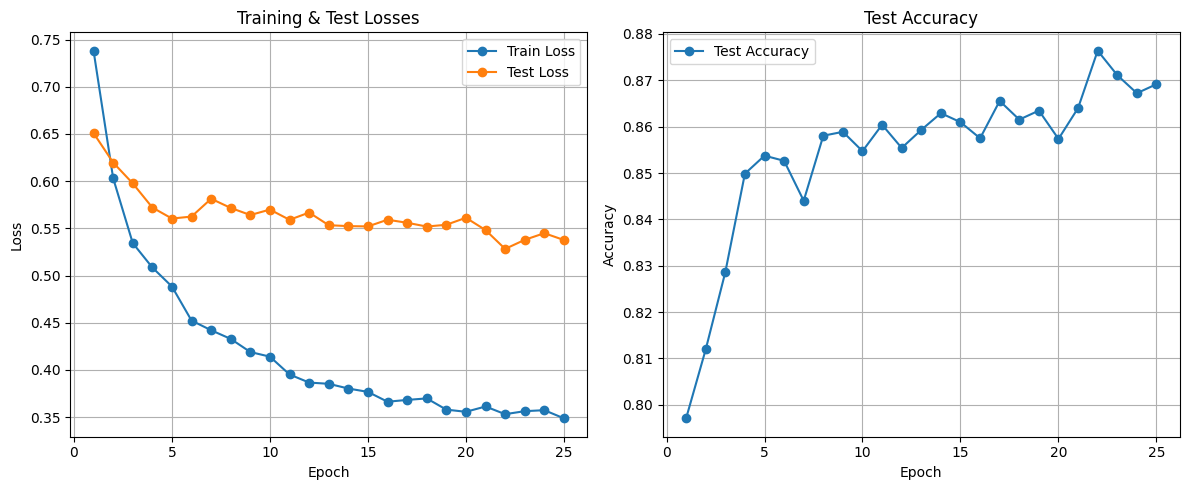

In [72]:
plot_losses_and_accuracy(train_losses, test_losses, accu_list, figsize=(12,5))

In [ ]:
'_'.join(sel_probes)

In [ ]:
if sel_probes == []:
    fname_model = f"cell_model_{ncrop}.pt"
else:
    fname_model = f"cell_model_{ncrop}_probes_{'_'.join(sel_probes)}.pt"


filename = os.path.join(cp.root_samples, fname_model)

try:
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "classes": classes,
        "class_to_index": class_to_index
    },  filename)
    print(f"File saved at '{filename}'")    
except:
    print(f"Error: could not save '{filename}'")

In [ ]:
epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(12,5))

#------ loss plot ------------------
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, test_losses, marker='o', label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("Training & Test Losses")

#----- accuracy plot ---------------
plt.subplot(1, 2, 2)
plt.plot(epochs_range, accu_list, marker='o', label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
mean_loss, accuracy = evaluate_loss_accuracy(model, train_loader)
# 20
# (0.9205801197687785, 0.5754133956906631)
# 30
# (0.8070158894062043, 0.6300317354267579)
mean_loss, accuracy

In [ ]:
mean_loss, accuracy = evaluate_loss_accuracy(model, test_loader)
# 20
# (1.0758121476173401, 0.5186236846500751)
# 30
# (1.0233093910217286, 0.5471855687322532)
mean_loss, accuracy